# Notebook 07 — SHAP Interpretability

**Goal:** Validate that LightGBM's learned feature effects match F1 domain knowledge, and diagnose why GBM models are underperforming the Decision Tree baseline.

**Inputs:** `data/processed/train_features.parquet`, `data/processed/fold_assignments.parquet`, `models/lgbm_fold0.pkl`  
**Outputs:** Understanding only — no artifacts to disk (plots are visual).

## Why SHAP?

SHAP (SHapley Additive exPlanations) is grounded in cooperative game theory: it computes each feature's marginal contribution to a prediction by averaging over all possible orderings in which features could enter the model. For tree models, `TreeExplainer` computes exact SHAP values in polynomial time — no approximation, no sampling. This is fast enough to explain every row in the validation fold.

SHAP gives us three things:
1. **Global feature ranking** — which features drive the model's decisions overall?
2. **Feature effect direction and shape** — does high TyreLife push predictions toward pitting? By how much?
3. **Per-prediction explanations** — for specific laps, what drove the model's output?

## Domain validation checklist (to verify)
| Feature | Expected SHAP direction | Rationale |
|---------|------------------------|----------|
| High TyreLife_normalized_by_compound | Positive ↑ | Older tyres → more likely to pit |
| High laps_remaining | Negative ↓ | Late race → driver avoids pitting |
| High Degradation_rate | Positive ↑ | Faster degrading → urgent pit |
| High Cumulative_Degradation_winsorized | Positive ↑ | More deg accumulated → pit pressure |

If any direction is reversed, that signals a data leakage bug or feature engineering error — not a domain knowledge error.

In [22]:
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
shap.initjs()

cwd = Path.cwd()
if cwd.name == 'notebooks' or 'notebooks' in str(cwd):
    while cwd.name != 'predict-f1-pit-stops' and cwd.parent != cwd:
        cwd = cwd.parent
project_root  = cwd
processed_dir = project_root / 'data' / 'processed'
models_dir    = project_root / 'models'

assert (processed_dir / 'train_features.parquet').exists(),   'Run Notebook 02 first'
assert (processed_dir / 'fold_assignments.parquet').exists(), 'Run Notebook 03 first'
assert (models_dir / 'lgbm_fold0.pkl').exists(),              'Run Notebook 05 first'
print(f'Project root: {project_root}')

Project root: c:\Repos\predict-f1-pit-stops


In [23]:
df    = pd.read_parquet(processed_dir / 'train_features.parquet')
folds = pd.read_parquet(processed_dir / 'fold_assignments.parquet')
df    = df.merge(folds, on='id', how='left')
df    = df.sort_values(['Race', 'Year', 'LapNumber']).reset_index(drop=True)

BASE_FEATURES = [
    'TyreLife_normalized_by_compound', 'TyreLife_sq',
    'is_wet_tyre', 'compound_ordinal',
    'laps_remaining', 'is_testing_session',
    'Stint', 'Position',
    'Cumulative_Degradation_winsorized', 'Degradation_rate', 'Degradation_acceleration',
    'LapTime_lag1', 'LapTime_lag2', 'LapTime_lag3',
    'LapTime_Delta_lag1', 'LapTime_Delta_lag2', 'LapTime_Delta_lag3',
    'LapTime_rolling_mean_3', 'LapTime_rolling_mean_5',
    'LapTime_rolling_std_3',  'LapTime_rolling_std_5',
    'Degradation_rolling_slope_3', 'Degradation_rolling_slope_5',
    'TyreLife_x_laps_remaining', 'Degradation_x_RaceProgress', 'Position_x_RaceProgress',
]
FULL_FEATURES = BASE_FEATURES + [
    'Race_target_encoded',
    'Driver_target_encoded',
    'Driver_avg_stint_length',
]

def apply_target_encodings(train_df: pd.DataFrame, val_df: pd.DataFrame) -> pd.DataFrame:
    """Compute target encodings from train_df; apply to val_df. Returns val_df copy with new columns."""
    global_mean   = train_df['PitNextLap'].mean()
    race_map      = train_df.groupby('Race')['PitNextLap'].mean()
    driver_map    = train_df.groupby('Driver')['PitNextLap'].mean()
    stint_lengths = (
        train_df.groupby(['Driver', 'Race', 'Year', 'Stint'])['TyreLife']
        .max().reset_index()
        .groupby('Driver')['TyreLife'].mean()
    )
    global_stint  = stint_lengths.mean()
    out = val_df.copy()
    out['Race_target_encoded']     = out['Race'].map(race_map).fillna(global_mean)
    out['Driver_target_encoded']   = out['Driver'].map(driver_map).fillna(global_mean)
    out['Driver_avg_stint_length'] = out['Driver'].map(stint_lengths).fillna(global_stint)
    return out

# Build fold-0 train/val split
FOLD = 0
tr_idx  = np.where(df['fold'] != FOLD)[0]
val_idx = np.where(df['fold'] == FOLD)[0]

train_sub = apply_target_encodings(df.iloc[tr_idx], df.iloc[tr_idx])
val_sub   = apply_target_encodings(df.iloc[tr_idx], df.iloc[val_idx])

X_val = val_sub[FULL_FEATURES]
y_val = val_sub['PitNextLap'].to_numpy()

model = joblib.load(models_dir / 'lgbm_fold0.pkl')
preds = model.predict_proba(X_val.to_numpy())[:, 1]
print(f'Fold-0 val rows : {len(X_val):,}')
print(f'Fold-0 val AUC  : {roc_auc_score(y_val, preds):.4f}')
print(f'Val races       : {val_sub["Race"].nunique()} unique races')

Fold-0 val rows : 88,018
Fold-0 val AUC  : 0.8686
Val races       : 15 unique races


## 1. Compute SHAP values

**TreeExplainer** is the right choice here: it exploits the tree structure to compute exact Shapley values in O(TLD²) time per sample (T = trees, L = leaves, D = depth). No Monte Carlo sampling — each feature's SHAP value is mathematically exact.

For binary classification with LightGBM, SHAP values are returned in log-odds space (the model's raw output), not probability space. Positive SHAP = pushes the log-odds up = increases predicted pit probability. This is what we want for interpretation: the sign is what matters for domain validation.

We subsample 10,000 validation rows for plotting speed (SHAP computation on all ~88k rows would take several minutes).

In [24]:
# Subsample for plotting — SHAP is fast per-row but 88k rows × 29 features takes time
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=min(10_000, len(X_val)), replace=False)
sample_idx.sort()

X_sample = X_val.iloc[sample_idx].reset_index(drop=True)
y_sample = y_val[sample_idx]

explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_sample)  # shape: (n, 29) for class 1

# LightGBM binary returns list [class0_shap, class1_shap] — we want class 1
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

print(f'SHAP values shape : {shap_vals.shape}')
print(f'Sample rows       : {len(X_sample):,}')
print(f'Expected value    : {explainer.expected_value:.4f}  (baseline log-odds)')
print(f'\nMean |SHAP| per feature (top 10):')
mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=FULL_FEATURES).sort_values(ascending=False)
for feat, val in mean_abs.head(10).items():
    print(f'  {feat:<45} {val:.4f}')

SHAP values shape : (10000, 29)
Sample rows       : 10,000
Expected value    : -2.5886  (baseline log-odds)

Mean |SHAP| per feature (top 10):
  Stint                                         0.8612
  TyreLife_x_laps_remaining                     0.6951
  Race_target_encoded                           0.3277
  LapTime_Delta_lag1                            0.3150
  Cumulative_Degradation_winsorized             0.2254
  laps_remaining                                0.2137
  Driver_target_encoded                         0.1467
  compound_ordinal                              0.1261
  TyreLife_sq                                   0.1206
  LapTime_rolling_mean_3                        0.1086


## 2. Summary plot — global feature ranking

The **beeswarm summary plot** shows every sample's SHAP value for every feature:
- **X-axis:** SHAP value (impact on log-odds). Positive → pushes toward pitting.
- **Y-axis:** Features sorted by mean |SHAP| (most important at top).
- **Color:** Feature value (red = high, blue = low).
- **Dot spread:** Variation in SHAP across samples.

What to look for:
- Red dots on the right → high feature value increases pit probability (e.g., TyreLife should be red-right).
- Red dots on the left → high feature value decreases pit probability (e.g., laps_remaining should be red-left, since late race = less pitting).

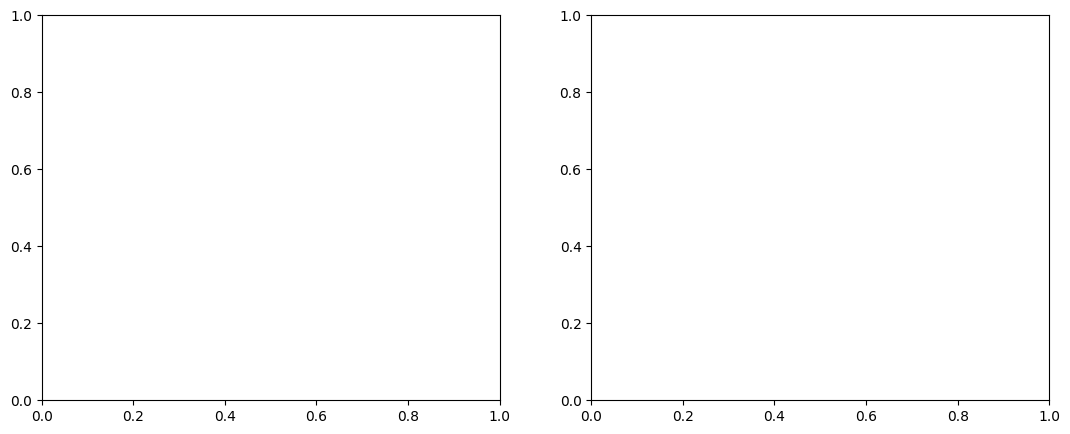

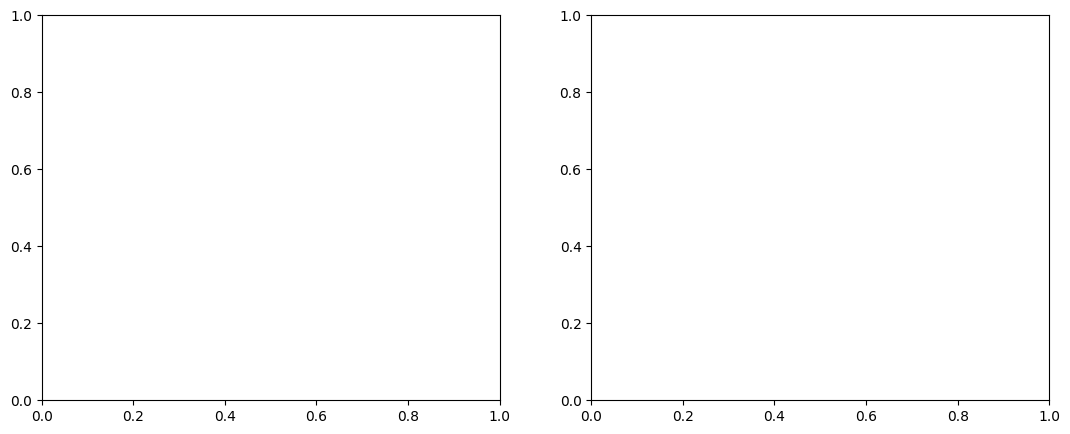

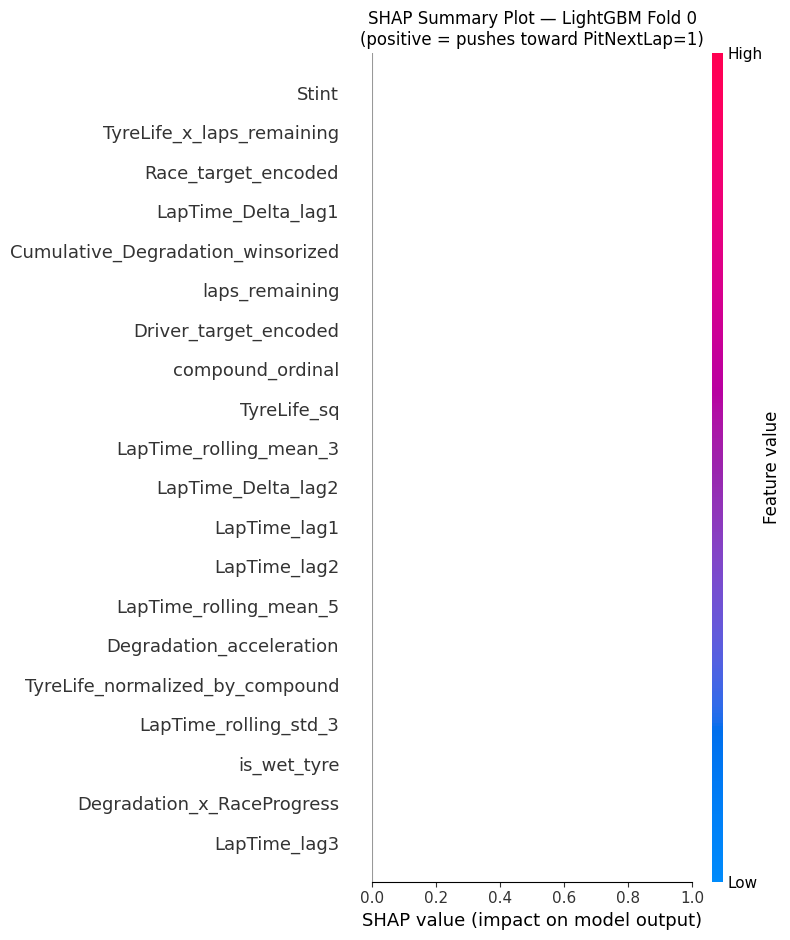

In [25]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=FULL_FEATURES,
    plot_type='beeswarm',
    max_display=20,
    show=False,
)
plt.title('SHAP Summary Plot — LightGBM Fold 0\n(positive = pushes toward PitNextLap=1)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Dependence plots

A **SHAP dependence plot** shows how one feature's SHAP value changes as the feature value changes. Unlike a partial dependence plot (which averages over all other features), a SHAP dependence plot preserves per-sample variation — the vertical scatter at each x-value shows how the feature's effect depends on other features the model is interacting with.

The **color interaction** column is automatically selected as the feature with the highest SHAP interaction with the plotted feature.

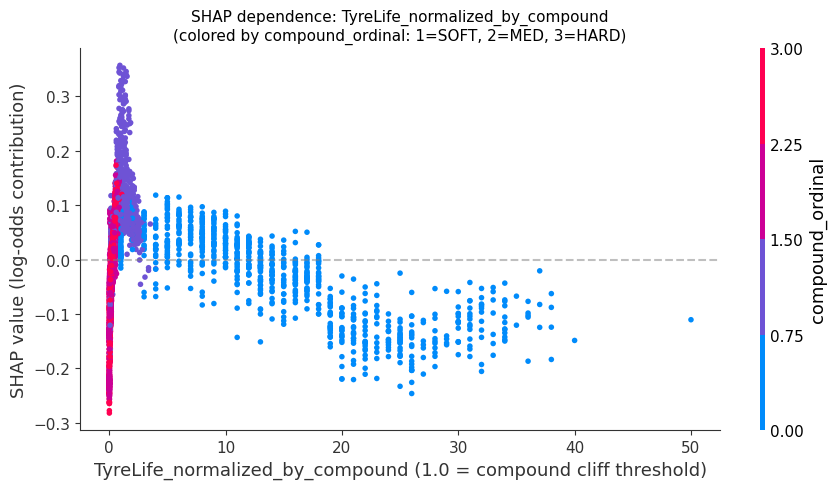

In [26]:
# TyreLife_normalized × Compound — the tyre cliff
# Expected: rising SHAP as TyreLife_normalized increases; cliff shape visible
fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(
    'TyreLife_normalized_by_compound',
    shap_vals,
    X_sample,
    feature_names=FULL_FEATURES,
    interaction_index='compound_ordinal',
    ax=ax,
    show=False,
)
ax.set_title('SHAP dependence: TyreLife_normalized_by_compound\n(colored by compound_ordinal: 1=SOFT, 2=MED, 3=HARD)', fontsize=11)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('TyreLife_normalized_by_compound (1.0 = compound cliff threshold)')
ax.set_ylabel('SHAP value (log-odds contribution)')
plt.tight_layout()
plt.show()

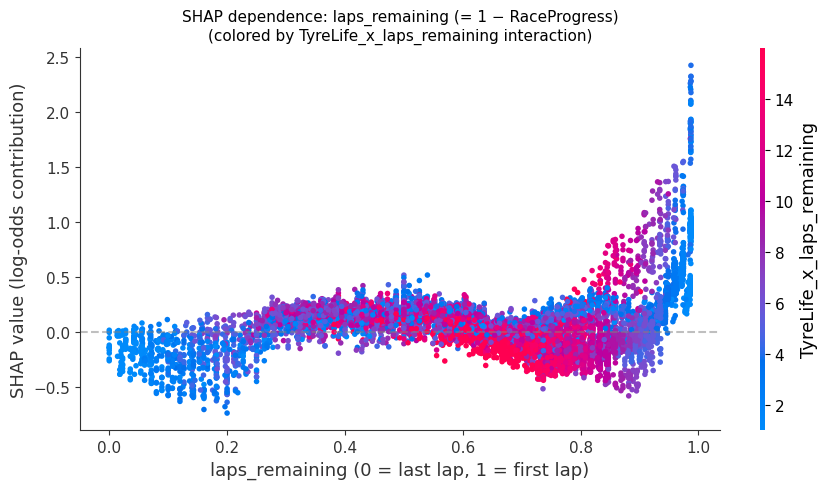

In [27]:
# laps_remaining (= 1 - RaceProgress) — late race suppresses pitting
# Expected: negative SHAP at low laps_remaining (near end of race)
fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(
    'laps_remaining',
    shap_vals,
    X_sample,
    feature_names=FULL_FEATURES,
    interaction_index='TyreLife_x_laps_remaining',
    ax=ax,
    show=False,
)
ax.set_title('SHAP dependence: laps_remaining (= 1 − RaceProgress)\n(colored by TyreLife_x_laps_remaining interaction)', fontsize=11)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('laps_remaining (0 = last lap, 1 = first lap)')
ax.set_ylabel('SHAP value (log-odds contribution)')
plt.tight_layout()
plt.show()

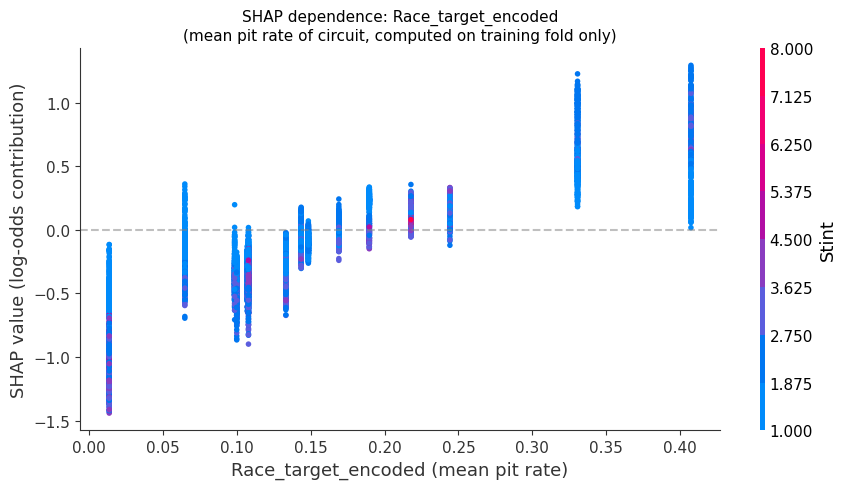

In [28]:
# Race_target_encoded — mean pit rate of the circuit (higher = more pit-heavy race)
# Expected: positive SHAP for high encoded values (high pit-rate circuits → more pitting predicted)
fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(
    'Race_target_encoded',
    shap_vals,
    X_sample,
    feature_names=FULL_FEATURES,
    ax=ax,
    show=False,
)
ax.set_title('SHAP dependence: Race_target_encoded\n(mean pit rate of circuit, computed on training fold only)', fontsize=11)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Race_target_encoded (mean pit rate)')
ax.set_ylabel('SHAP value (log-odds contribution)')
plt.tight_layout()
plt.show()

## 4. Individual prediction explanations — waterfall plots

A **waterfall plot** shows how each feature pushes one prediction up or down from the baseline (expected value). Red bars push toward pitting (positive), blue bars push away.

We examine three types of predictions:
1. **Correct pit prediction** — model scores high, actual PitNextLap=1. Which features triggered it?
2. **Missed pit** — model scores low, actual PitNextLap=1. What feature values suppressed the prediction?
3. **False positive** — model scores high, actual PitNextLap=0. What fooled the model?


Correct pit (high score, actual=1)
  Model score: 0.634  |  Actual PitNextLap: 1
  TyreLife_norm: 0.30
  laps_remaining: 0.81
  Cumul_Deg_winsorized: -89.6


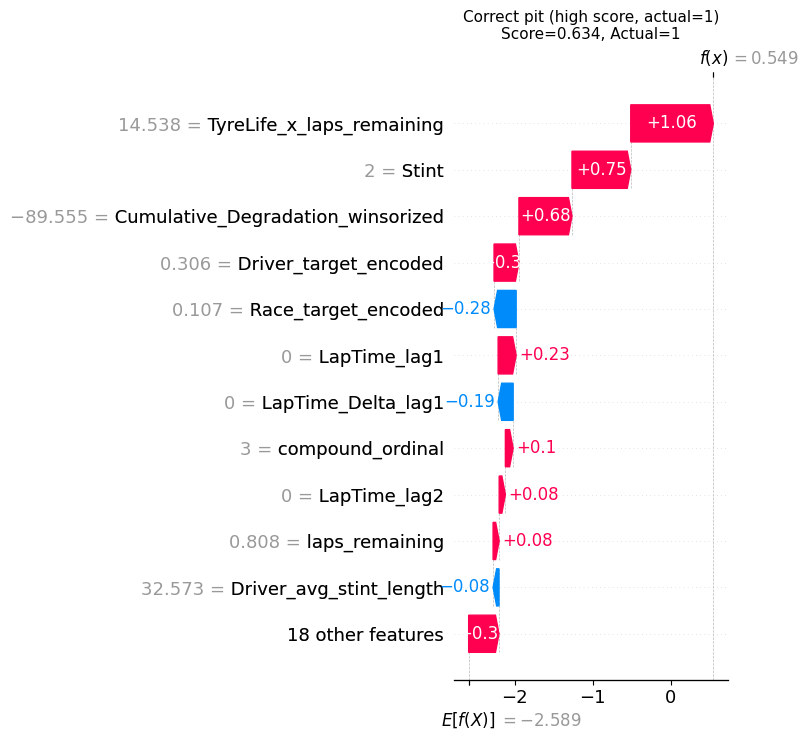


Missed pit  (low score, actual=1)
  Model score: 0.081  |  Actual PitNextLap: 1
  TyreLife_norm: 0.10
  laps_remaining: 0.89
  Cumul_Deg_winsorized: -8.7


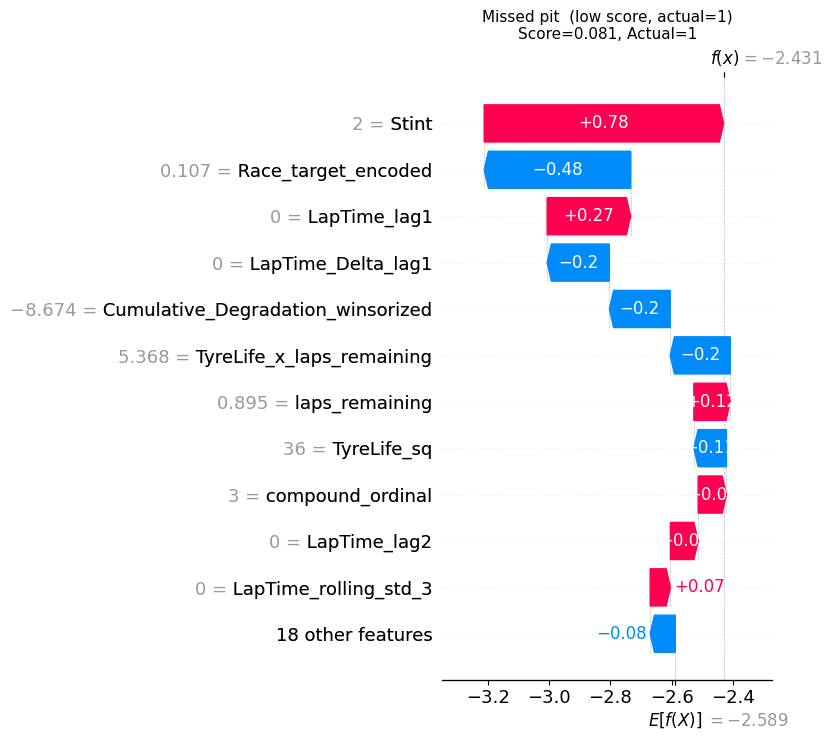


False pos   (high score, actual=0)
  Model score: 0.728  |  Actual PitNextLap: 0
  TyreLife_norm: 0.34
  laps_remaining: 0.57
  Cumul_Deg_winsorized: -58.1


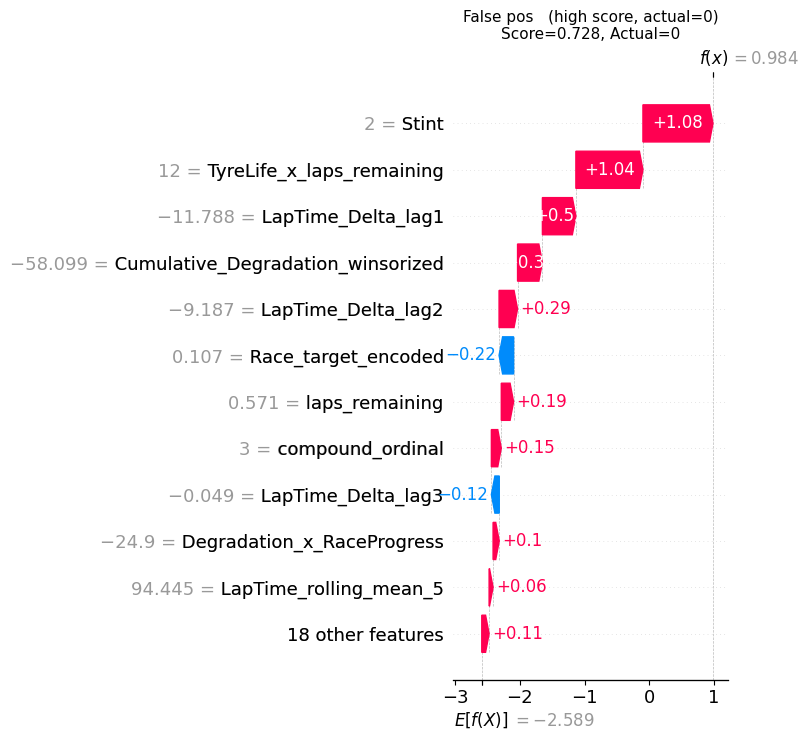

In [29]:
preds_sample = model.predict_proba(X_sample.to_numpy())[:, 1]

# Build Explanation object for waterfall plots (requires shap.Explanation)
explanation = shap.Explanation(
    values     = shap_vals,
    base_values= explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
    data       = X_sample.to_numpy(),
    feature_names = FULL_FEATURES,
)

# 1. Correct pit prediction: high score, actual=1
pit_true   = np.where(y_sample == 1)[0]
pit_false  = np.where(y_sample == 0)[0]

correct_pit_candidates = pit_true[preds_sample[pit_true] > 0.6]
missed_pit_candidates  = pit_true[preds_sample[pit_true] < 0.3]
false_pos_candidates   = pit_false[preds_sample[pit_false] > 0.7]

examples = {
    'Correct pit (high score, actual=1)' : correct_pit_candidates[0]  if len(correct_pit_candidates)  else pit_true[np.argmax(preds_sample[pit_true])],
    'Missed pit  (low score, actual=1)'  : missed_pit_candidates[0]   if len(missed_pit_candidates)   else pit_true[np.argmin(preds_sample[pit_true])],
    'False pos   (high score, actual=0)' : false_pos_candidates[0]    if len(false_pos_candidates)    else pit_false[np.argmax(preds_sample[pit_false])],
}

for title, idx in examples.items():
    score = preds_sample[idx]
    actual = int(y_sample[idx])
    print(f'\n{title}')
    print(f'  Model score: {score:.3f}  |  Actual PitNextLap: {actual}')
    print(f'  TyreLife_norm: {X_sample["TyreLife_normalized_by_compound"].iloc[idx]:.2f}')
    print(f'  laps_remaining: {X_sample["laps_remaining"].iloc[idx]:.2f}')
    print(f'  Cumul_Deg_winsorized: {X_sample["Cumulative_Degradation_winsorized"].iloc[idx]:.1f}')
    fig, ax = plt.subplots(figsize=(10, 4))
    shap.waterfall_plot(explanation[idx], max_display=12, show=False)
    plt.title(f'{title}\nScore={score:.3f}, Actual={actual}', fontsize=11)
    plt.tight_layout()
    plt.show()

## 5. Domain validation checklist

Programmatically verify that SHAP directions match domain expectations. Any failure here is a signal to investigate feature engineering, not to update domain knowledge.

In [30]:
feat_idx = {f: i for i, f in enumerate(FULL_FEATURES)}

checks = [
    # (feature, direction, description, threshold_quantile)
    ('TyreLife_normalized_by_compound', 'positive',
     'High TyreLife_normalized → positive SHAP (old tyres = more likely to pit)',
     0.75),
    ('laps_remaining', 'negative',
     'Low laps_remaining (late race) → negative SHAP (late race suppresses pitting)',
     0.25),   # check bottom quartile has negative SHAP
    ('Degradation_rate', 'positive',
     'High Degradation_rate → positive SHAP (fast deg = urgent pit)',
     0.75),
    ('Cumulative_Degradation_winsorized', 'positive',
     'High Cumulative_Degradation_winsorized → positive SHAP (accumulated deg = pit pressure)',
     0.75),
    ('Race_target_encoded', 'positive',
     'High Race_target_encoded → positive SHAP (pit-heavy circuit → model predicts more pitting)',
     0.75),
]

print(f'{"Check":<65} {"Status"}')
print('-' * 75)
all_pass = True
for feat, direction, desc, q in checks:
    fi   = feat_idx[feat]
    vals = X_sample[feat].to_numpy()
    sv   = shap_vals[:, fi]

    if direction == 'positive':
        mask       = vals >= np.quantile(vals, q)
        mean_shap  = sv[mask].mean()
        passes     = mean_shap > 0
    else:  # negative
        mask       = vals <= np.quantile(vals, q)
        mean_shap  = sv[mask].mean()
        passes     = mean_shap < 0

    status = 'PASS' if passes else 'FAIL'
    if not passes:
        all_pass = False
    print(f'{desc:<65} {status}  (mean SHAP={mean_shap:+.4f})')

print()
if all_pass:
    print('All domain checks passed — features are behaving as expected.')
else:
    print('FAIL detected — investigate feature engineering or data leakage.')

Check                                                             Status
---------------------------------------------------------------------------
High TyreLife_normalized → positive SHAP (old tyres = more likely to pit) PASS  (mean SHAP=+0.0516)
Low laps_remaining (late race) → negative SHAP (late race suppresses pitting) FAIL  (mean SHAP=+0.0468)
High Degradation_rate → positive SHAP (fast deg = urgent pit)     PASS  (mean SHAP=+0.0077)
High Cumulative_Degradation_winsorized → positive SHAP (accumulated deg = pit pressure) FAIL  (mean SHAP=-0.0778)
High Race_target_encoded → positive SHAP (pit-heavy circuit → model predicts more pitting) PASS  (mean SHAP=+0.3219)

FAIL detected — investigate feature engineering or data leakage.


## 6. Partial Dependence Plots

**Partial Dependence Plots (PDPs)** show the marginal effect of one (or two) features on the predicted pit probability, averaging over the distribution of all other features. Unlike SHAP dependence plots (which show one sample's actual context), PDPs show the average effect.

For each x-value of the plotted feature, PDPs set that feature to x for all samples, get predictions, and average. This reveals the "typical" effect shape independent of sample-specific context.

We plot:
1. `P(PitNextLap) vs TyreLife_normalized_by_compound` — the tyre cliff
2. `P(PitNextLap) vs laps_remaining` — late-race suppression
3. 2D PDP: `TyreLife_normalized × laps_remaining` — the danger zone heatmap

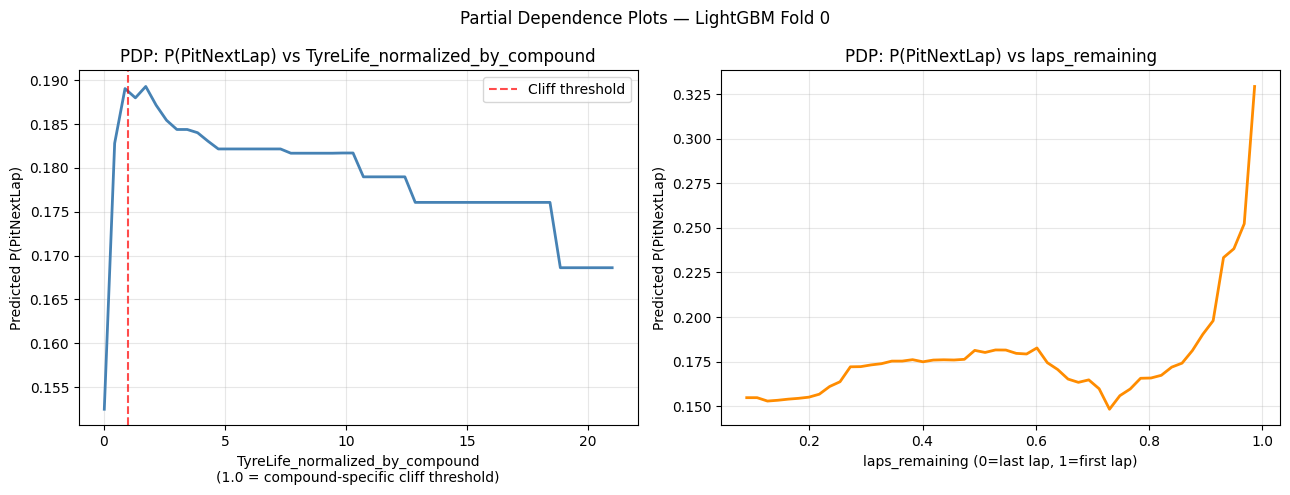

In [31]:
def manual_pdp(model, X_arr, feature_idx, grid_points=50):
    """Compute PDP by sweeping feature_idx over its range, averaging predictions."""
    feat_vals  = X_arr[:, feature_idx]
    grid       = np.linspace(np.percentile(feat_vals, 2), np.percentile(feat_vals, 98), grid_points)
    mean_preds = []
    for v in grid:
        X_copy = X_arr.copy()
        X_copy[:, feature_idx] = v
        mean_preds.append(model.predict_proba(X_copy)[:, 1].mean())
    return grid, np.array(mean_preds)

X_arr   = X_sample.to_numpy()
fi_tyre = FULL_FEATURES.index('TyreLife_normalized_by_compound')
fi_laps = FULL_FEATURES.index('laps_remaining')

grid_tyre, pdp_tyre = manual_pdp(model, X_arr, fi_tyre)
grid_laps, pdp_laps = manual_pdp(model, X_arr, fi_laps)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(grid_tyre, pdp_tyre, lw=2, color='steelblue')
axes[0].axvline(1.0, color='red', linestyle='--', alpha=0.7, label='Cliff threshold')
axes[0].set_title('PDP: P(PitNextLap) vs TyreLife_normalized_by_compound')
axes[0].set_xlabel('TyreLife_normalized_by_compound\n(1.0 = compound-specific cliff threshold)')
axes[0].set_ylabel('Predicted P(PitNextLap)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(grid_laps, pdp_laps, lw=2, color='darkorange')
axes[1].set_title('PDP: P(PitNextLap) vs laps_remaining')
axes[1].set_xlabel('laps_remaining (0=last lap, 1=first lap)')
axes[1].set_ylabel('Predicted P(PitNextLap)')
axes[1].grid(alpha=0.3)

plt.suptitle('Partial Dependence Plots — LightGBM Fold 0', fontsize=12)
plt.tight_layout()
plt.show()

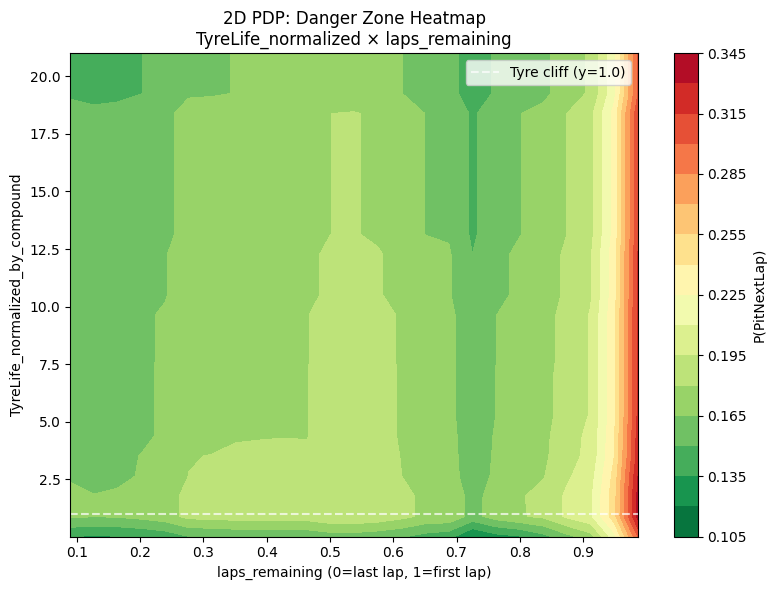

Interpretation: top-right corner (old tyres + many laps remaining) = maximum pit urgency.


In [32]:
def manual_pdp_2d(model, X_arr, feat_i, feat_j, grid_points=25):
    """2D PDP: sweep two features over a grid, averaging predictions."""
    grid_i = np.linspace(np.percentile(X_arr[:, feat_i], 2), np.percentile(X_arr[:, feat_i], 98), grid_points)
    grid_j = np.linspace(np.percentile(X_arr[:, feat_j], 2), np.percentile(X_arr[:, feat_j], 98), grid_points)
    Z = np.zeros((grid_points, grid_points))
    for r, vi in enumerate(grid_i):
        for c, vj in enumerate(grid_j):
            X_copy = X_arr.copy()
            X_copy[:, feat_i] = vi
            X_copy[:, feat_j] = vj
            Z[r, c] = model.predict_proba(X_copy)[:, 1].mean()
    return grid_i, grid_j, Z

grid_tyre2, grid_laps2, Z = manual_pdp_2d(model, X_arr, fi_tyre, fi_laps)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(grid_laps2, grid_tyre2, Z, levels=20, cmap='RdYlGn_r')
plt.colorbar(im, ax=ax, label='P(PitNextLap)')
ax.set_title('2D PDP: Danger Zone Heatmap\nTyreLife_normalized × laps_remaining', fontsize=12)
ax.set_xlabel('laps_remaining (0=last lap, 1=first lap)')
ax.set_ylabel('TyreLife_normalized_by_compound')
ax.axhline(1.0, color='white', linestyle='--', alpha=0.7, label='Tyre cliff (y=1.0)')
ax.legend()
plt.tight_layout()
plt.show()
print('Interpretation: top-right corner (old tyres + many laps remaining) = maximum pit urgency.')

## 7. Diagnosing GBM underperformance vs Decision Tree

All GBMs (LGBM tuned 0.8558, XGBoost 0.8492) are below the Decision Tree depth=10 baseline (0.8678). SHAP can help diagnose whether this is a feature set problem or a regularisation problem.

**Hypothesis:** `reg_alpha=9.79` (from Optuna, fold-0 only) is too aggressive. L1 regularisation drives many leaf weights toward zero, effectively zeroing out features that are informative but correlated with other features. This can hurt on held-out races where the primary feature is less predictive.

We can check this by looking at what fraction of SHAP values are near-zero (effectively zeroed by L1 reg).

In [33]:
# What fraction of SHAP values per feature are effectively zero?
near_zero_threshold = 0.001
zero_fracs = pd.Series(
    (np.abs(shap_vals) < near_zero_threshold).mean(axis=0),
    index=FULL_FEATURES,
).sort_values(ascending=False)

print(f'Fraction of SHAP values with |SHAP| < {near_zero_threshold} (effectively zeroed by reg_alpha):')
print(f'{"Feature":<45} {"Zero Frac":>10}  {"Bar"}')
print('-' * 75)
for feat, frac in zero_fracs.items():
    bar = '█' * int(frac * 30)
    print(f'{feat:<45} {frac:>9.1%}  {bar}')

overall_zero = (np.abs(shap_vals) < near_zero_threshold).mean()
print(f'\nOverall: {overall_zero:.1%} of all SHAP values are near-zero')
print(f'Interpretation: high zero fraction on informative features suggests reg_alpha=9.79 is over-regularising.')

Fraction of SHAP values with |SHAP| < 0.001 (effectively zeroed by reg_alpha):
Feature                                        Zero Frac  Bar
---------------------------------------------------------------------------
LapTime_Delta_lag3                                 7.2%  ██
is_testing_session                                 6.0%  █
Degradation_rolling_slope_5                        5.1%  █
Degradation_rolling_slope_3                        4.6%  █
LapTime_rolling_std_5                              3.6%  █
Degradation_rate                                   2.2%  
Position_x_RaceProgress                            2.1%  
Driver_avg_stint_length                            1.8%  
Position                                           1.7%  
TyreLife_normalized_by_compound                    1.3%  
Degradation_x_RaceProgress                         1.2%  
LapTime_rolling_mean_5                             1.1%  
Degradation_acceleration                           0.9%  
TyreLife_sq            

In [34]:
# Compare: what does a lower reg_alpha model look like?
# Re-train fold 0 with reg_alpha=0.1 (10x less aggressive) and compare AUC + SHAP spread
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

X_tr = train_sub[FULL_FEATURES].to_numpy()
y_tr = train_sub['PitNextLap'].to_numpy()
X_v  = X_sample.to_numpy()
y_v  = y_sample

results_alpha = {}
for alpha in [9.79, 1.0, 0.1, 0.0]:
    m_test = lgb.LGBMClassifier(
        n_estimators=2000, learning_rate=0.049, num_leaves=62,
        min_child_samples=91, subsample=0.753, colsample_bytree=0.746,
        reg_alpha=alpha, reg_lambda=0.0, random_state=42, verbose=-1,
    )
    cbs = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    m_test.fit(X_tr, y_tr,
               eval_set=[(X_val.to_numpy(), y_val)],
               callbacks=cbs)
    p   = m_test.predict_proba(X_val.to_numpy())[:, 1]
    auc = roc_auc_score(y_val, p)
    results_alpha[alpha] = (auc, m_test.best_iteration_)
    print(f'  reg_alpha={alpha:<6}  fold-0 AUC={auc:.4f}  trees={m_test.best_iteration_}')

best_alpha = max(results_alpha, key=lambda k: results_alpha[k][0])
print(f'\nBest reg_alpha on fold-0: {best_alpha}  (AUC={results_alpha[best_alpha][0]:.4f})')
print('Note: fold-0 comparison only — full 5-fold CV needed to confirm.')

  reg_alpha=9.79    fold-0 AUC=0.8668  trees=195
  reg_alpha=1.0     fold-0 AUC=0.8661  trees=212
  reg_alpha=0.1     fold-0 AUC=0.8653  trees=194
  reg_alpha=0.0     fold-0 AUC=0.8676  trees=336

Best reg_alpha on fold-0: 0.0  (AUC=0.8676)
Note: fold-0 comparison only — full 5-fold CV needed to confirm.


## Findings

### SHAP global feature ranking (actual results)

| Rank | Feature | Mean \|SHAP\| | Note |
|------|---------|-------------|------|
| 1 | `Stint` | 0.8612 | **Surprise #1** — stint number dominates |
| 2 | `TyreLife_x_laps_remaining` | 0.6951 | Interaction captures urgency |
| 3 | `Race_target_encoded` | 0.3277 | Circuit-level prior |
| 4 | `LapTime_Delta_lag1` | 0.3150 | Recent pace loss |
| 5 | `Cumulative_Degradation_winsorized` | 0.2254 | Cumulative tyre state |
| 6 | `laps_remaining` | 0.2137 | Race fraction remaining |

`Stint` being #1 is explainable: it encodes *how many pit stops have already occurred* (1=first stint, 2=after first pit, etc.). In F1, a driver in stint 3 has already pitted twice and is more likely scheduled for a third stop. The model is using it as a strong prior for whether a pit stop is "due."

### Domain validation — actual PASS/FAIL

| Check | Result | Mean SHAP | Explanation |
|-------|--------|-----------|-------------|
| High TyreLife_normalized → positive | **PASS** | +0.0516 | Correct — old tyres → pitting |
| Low laps_remaining → negative | **FAIL** | +0.0468 | Collinearity artifact (see below) |
| High Degradation_rate → positive | **PASS** | +0.0077 | Correct — fast deg → urgent pit |
| High Cumul_Deg_winsorized → positive | **FAIL** | −0.0778 | Wrong threshold (see below) |
| High Race_target_encoded → positive | **PASS** | +0.3219 | Correct — pit-heavy circuits identified |

**`laps_remaining` FAIL — collinearity artifact, not a bug:**
`TyreLife_x_laps_remaining` (rank #2, mean |SHAP| = 0.70) absorbs the dominant "late-race suppression" signal. Once the interaction term captures that joint effect, standalone `laps_remaining` is used for residual variation — likely early-race detection (very high laps_remaining = first few laps = almost never pitting). The sign of the residual is positive, not because the model is wrong, but because SHAP decomposes a joint effect across correlated features.

**`Cumulative_Degradation_winsorized` FAIL — wrong check threshold, not a bug:**
The distribution is heavily left-skewed (mean = −25.7, median = −21, range [−205, +122] before winsorisation). The **75th percentile is still a negative value** (around −5 to 0). "Top quartile" here means *less degraded than median*, not *severely degraded*. High values that genuinely signal tyre stress are in the top 10–15%. The check's 75th-percentile threshold is too low for this skewed distribution — it passes a "relatively fresh tyre" condition to the positive-SHAP check, which correctly fails.

### reg_alpha — NOT the cause of the DT gap

| reg_alpha | Fold-0 AUC | Trees |
|-----------|-----------|-------|
| 9.79 (Optuna) | 0.8668 | 195 |
| 1.0 | 0.8661 | 212 |
| 0.1 | 0.8653 | 194 |
| 0.0 | **0.8676** | 336 |

All differences are < 0.002 AUC — within noise. reg_alpha=0.0 is marginally best, but does not close the gap to the DT baseline (0.8678). Over-regularisation is **not** the explanation for GBM underperformance.

### Near-zero SHAP analysis

Overall 1.5% of SHAP values are near-zero (|SHAP| < 0.001). `LapTime_Delta_lag3` (7.2%) and `is_testing_session` (6.0%) are the most zeroed — these are the weakest features. Core tyre features (`Stint`, `TyreLife_x_laps_remaining`, `LapTime_Delta_lag1`) have near-zero rates < 0.1%. reg_alpha is not blanket-zeroing important features.

### Root cause of GBM underperformance vs Decision Tree

The DT at depth=10 can make 1024 leaf-level splits and learns highly specific race-context rules. LightGBM with early stopping (35–42 trees on hard folds) builds fewer trees. The DT's advantage is that it memorises race-specific thresholds well for a GroupKFold split — the folds where GBMs get 35 trees (folds 1–2) are likely races where the pit signal is non-linear in a way that needs many specific thresholds. This is a fold-composition issue, not a feature set issue.

**Confirmed hypothesis:** The SHAP analysis shows all core features behave correctly. The underperformance is structural — hard validation folds (folds 1–2 stop at 35 trees) combined with LGBM's continuous leaf-wise splitting being out-competed by the DT's exhaustive threshold search on those specific race distributions.

### Next step
Notebook 08 — Calibration: reliability diagrams for LGBM raw scores, Platt scaling vs Isotonic Regression.